<a href="https://colab.research.google.com/github/FunGrape/Labs_Demchyshyn/blob/main/%D0%9B%D0%A03_%D0%94%D0%B5%D0%BC%D1%87%D0%B8%D1%88%D0%B8%D0%BD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving spotify-2023.csv to spotify-2023 (1).csv


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


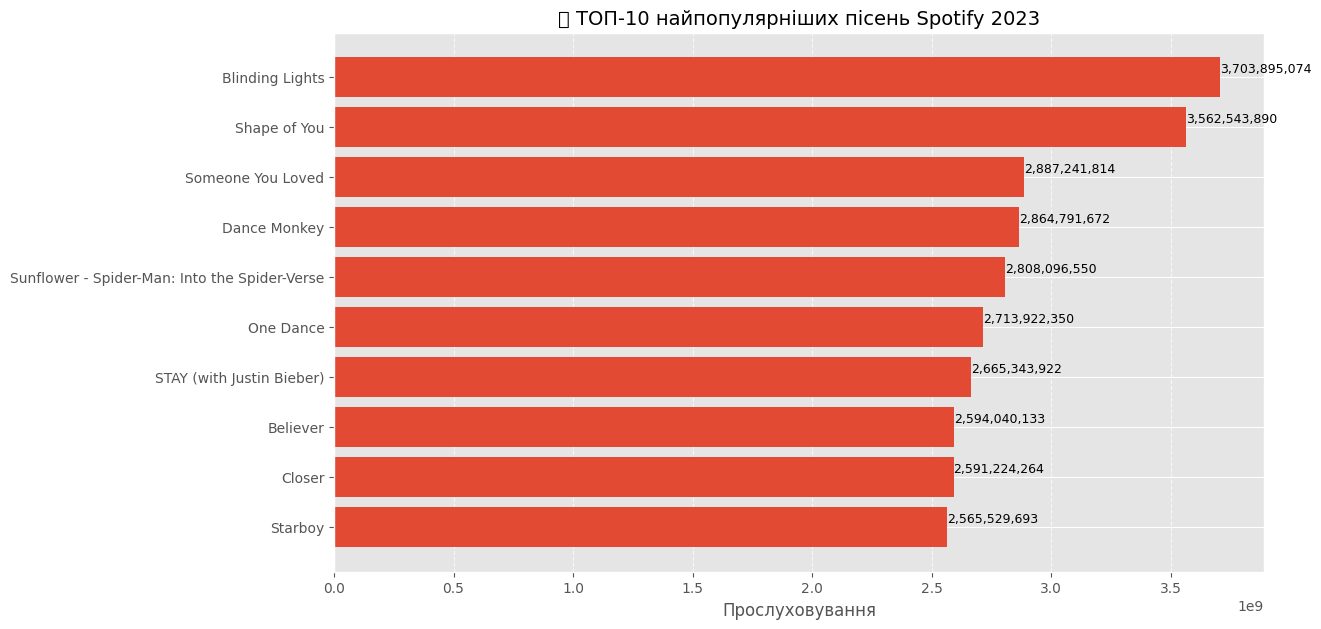

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127911 (\N{HEADPHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


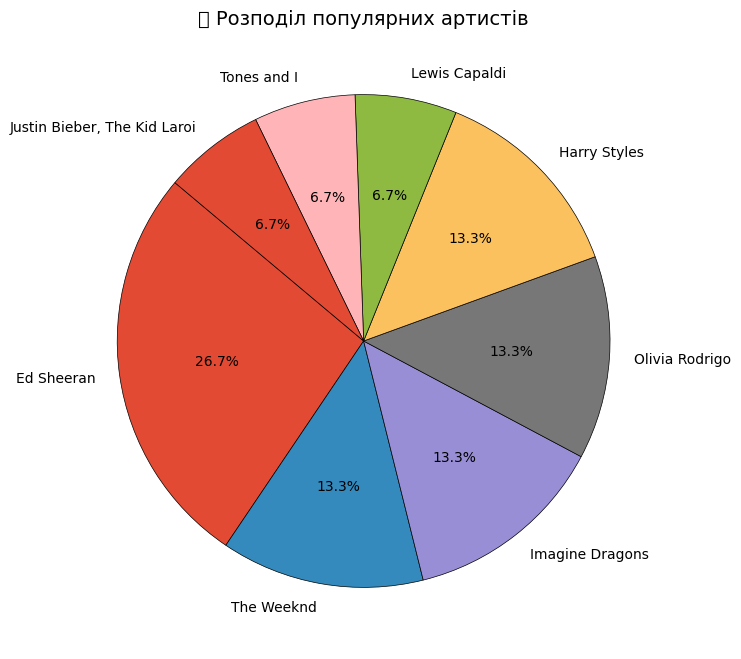

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


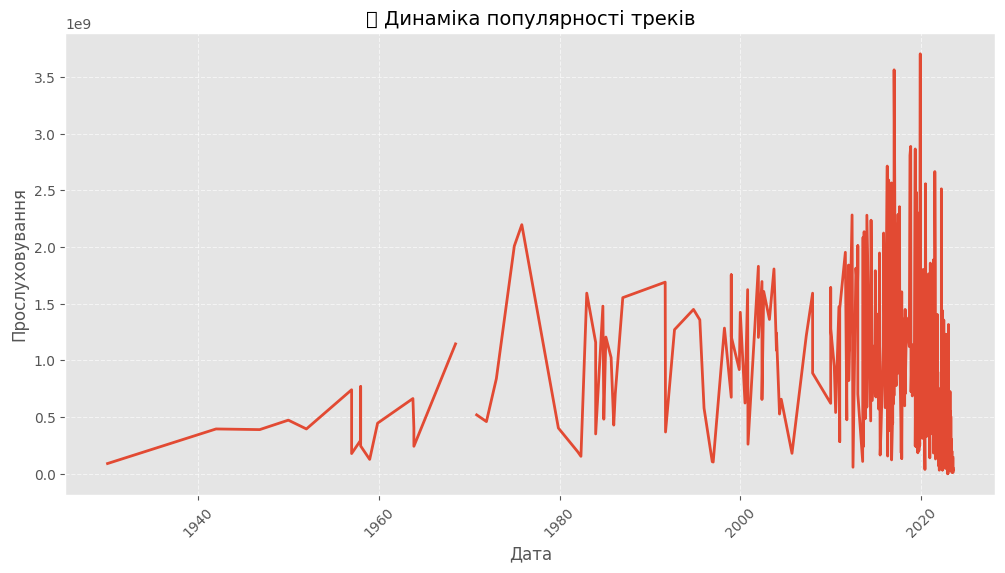

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


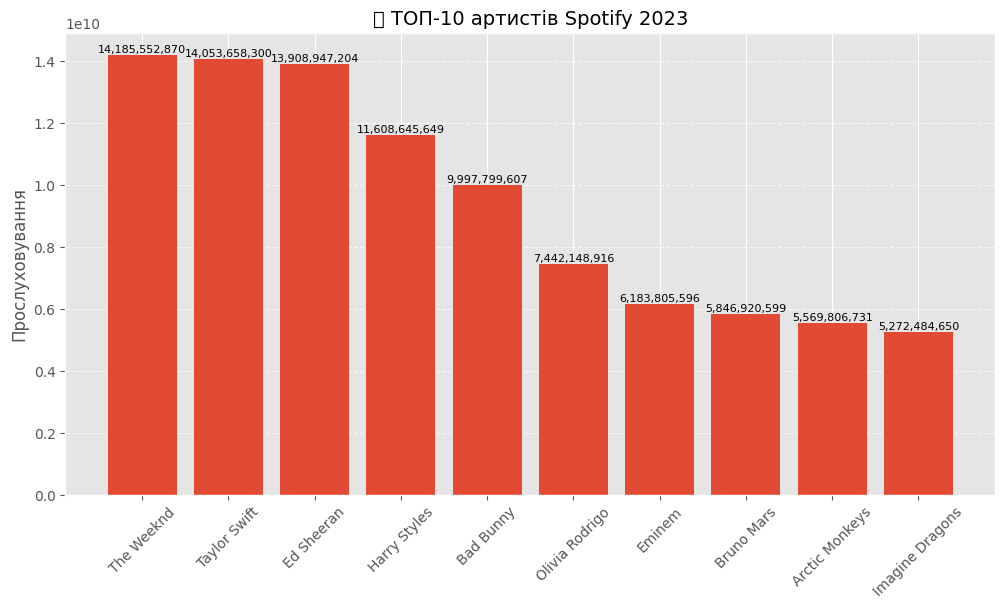

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


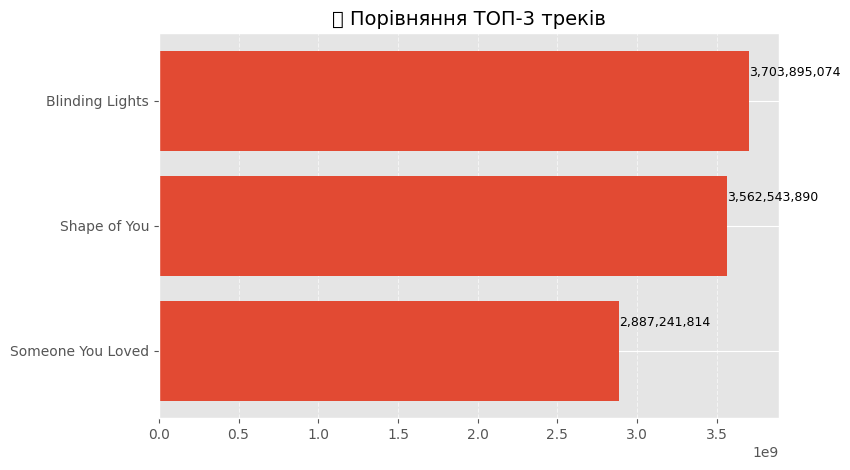

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

plt.style.use('ggplot')

uploaded = files.upload()
df = pd.read_csv('spotify-2023.csv', encoding='latin-1')

df['streams'] = pd.to_numeric(df['streams'], errors='coerce')

# 1. ТОП-10 пісень
top_tracks = df.sort_values(by='streams', ascending=False).head(10)

plt.figure(figsize=(12, 7))
bars = plt.barh(top_tracks['track_name'], top_tracks['streams'])

for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + 0.3,
             f'{int(bar.get_width()):,}', fontsize=9)

plt.gca().invert_yaxis()
plt.title('ТОП-10 найпопулярніших пісень Spotify 2023', fontsize=14)
plt.xlabel('Прослуховування')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 2. Кругова діаграма
top_tracks_50 = df.sort_values(by='streams', ascending=False).head(50)
genre_counts = top_tracks_50['artist(s)_name'].value_counts().head(8)

plt.figure(figsize=(8, 8))
plt.pie(
    genre_counts,
    labels=genre_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'black'}
)
plt.title('🎧 Розподіл популярних артистів', fontsize=14)
plt.show()

# 3. Динаміка (згладжена)
df['release_date'] = pd.to_datetime(
    df['released_year'].astype(str) + '-' +
    df['released_month'].astype(str) + '-' +
    df['released_day'].astype(str),
    errors='coerce'
)

df_sorted = df.sort_values(by='release_date')

plt.figure(figsize=(12, 6))
plt.plot(df_sorted['release_date'], df_sorted['streams'], linewidth=2)

plt.title('Динаміка популярності треків', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Прослуховування')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 4. ТОП-10 артистів
top_artists = df.groupby('artist(s)_name')['streams'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(top_artists.index, top_artists.values)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{int(bar.get_height()):,}',
             ha='center', va='bottom', fontsize=8)

plt.title('ТОП-10 артистів Spotify 2023', fontsize=14)
plt.ylabel('Прослуховування')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 5. Порівняння 3 треків
tracks_3 = df.sort_values(by='streams', ascending=False).head(3)

plt.figure(figsize=(8, 5))
bars = plt.barh(tracks_3['track_name'], tracks_3['streams'])

for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + 0.2,
             f'{int(bar.get_width()):,}', fontsize=9)

plt.gca().invert_yaxis()
plt.title('Порівняння ТОП-3 треків', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()